# 🎬 Advanced Movie Dataset Analysis

---

## 📌 Table of Contents
1. [Environment Setup & Imports](#1)
2. [Data Loading & Inspection](#2)
3. [Data Cleaning & Feature Engineering](#3)
4. [Univariate Analysis](#4)
5. [Bivariate & Multivariate Analysis](#5)
6. [Genre Deep Dive](#6)
7. [Temporal Analysis](#7)
8. [Popularity & Vote Analysis](#8)
9. [Correlation & Statistical Testing](#9)
10. [Top-N Rankings & Leaderboards](#10)
11. [NLP — Overview Text Analysis](#11)
12. [Cluster Analysis](#12)
13. [Final Conclusions & Insights](#13)

---

<a id='1'></a>
## 1. 🛠️ Environment Setup & Imports

We import a rich toolkit: standard data science libraries, advanced visualization (Plotly, Seaborn, Matplotlib), NLP tools, and statistical/ML libraries.

In [2]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import kruskal, shapiro, spearmanr

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── NLP ───────────────────────────────────────────────────────────────────────
from collections import Counter
import re
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except ImportError:
    WC_AVAILABLE = False

# ── Display Config ────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PALETTE = px.colors.qualitative.Vivid
CINEMATIC = ['#0d1b2a','#1b263b','#415a77','#778da9','#e0e1dd']

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


<a id='2'></a>
## 2. 📂 Data Loading & Inspection

Load the raw CSV and perform a thorough first-look inspection: shape, dtypes, missing values, cardinality, and sample rows.

In [3]:
df_raw = pd.read_csv('dataset/mymoviedb.csv', lineterminator='\n')
print(f'Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Shape  : 9,827 rows × 9 columns


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.95,8940,8.30,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.66,1151,8.10,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.09,122,6.30,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...


In [4]:
# ── Data Quality Report ───────────────────────────────────────────────────────
quality = pd.DataFrame({
    'dtype'     : df_raw.dtypes,
    'non_null'  : df_raw.notna().sum(),
    'null_count': df_raw.isna().sum(),
    'null_%'    : (df_raw.isna().mean()*100).round(2),
    'unique'    : df_raw.nunique(),
    'sample_val': [str(df_raw[c].dropna().iloc[0]) for c in df_raw.columns]
})
quality.style.background_gradient(subset=['null_%'], cmap='YlOrRd')

,dtype,non_null,null_count,null_%,unique,sample_val
Release_Date,object,9827,0,0.000000,5893,2021-12-15
Title,object,9827,0,0.000000,9513,Spider-Man: No Way Home
Overview,object,9827,0,0.000000,9822,"Peter Parker is unmasked and no longer able to separate his normal life from the high-stakes of being a super-hero. When he asks for help from Doctor Strange the stakes become even more dangerous, forcing him to discover what it truly means to be Spider-Man."
Popularity,float64,9827,0,0.000000,8160,5083.954
Vote_Count,int64,9827,0,0.000000,3266,8940
Vote_Average,float64,9827,0,0.000000,74,8.3
Original_Language,object,9827,0,0.000000,43,en
Genre,object,9827,0,0.000000,2337,"Action, Adventure, Science Fiction"
Poster_Url,object,9827,0,0.000000,9827,https://image.tmdb.org/t/p/original/1g0dhYtq4irTY1GPXvft6k4YLjm.jpg


In [5]:
print('─'*50)
print('DESCRIPTIVE STATISTICS — Numeric Columns')
print('─'*50)
df_raw.describe().round(2)

──────────────────────────────────────────────────
DESCRIPTIVE STATISTICS — Numeric Columns
──────────────────────────────────────────────────


,Popularity,Vote_Count,Vote_Average
count,9827.00,9827.00,9827.00
mean,40.33,1392.81,6.44
std,108.87,2611.21,1.13
min,13.35,0.00,0.00
25%,16.13,146.00,5.90
50%,21.20,444.00,6.50
75%,35.19,1376.00,7.10
max,5083.95,31077.00,10.00


<a id='3'></a>
## 3. 🔧 Data Cleaning & Feature Engineering

We apply a full cleaning pipeline:
- Parse dates → extract year & decade
- Explode multi-valued Genre column
- Cap popularity outliers
- Derive new features: `vote_bucket`, `popularity_tier`, `era`
- Preserve a **full-row version** for NLP use

In [6]:
df = df_raw.copy()

# ── Dates ─────────────────────────────────────────────────────────────────────
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Year']   = df['Release_Date'].dt.year.astype('Int64')
df['Month']  = df['Release_Date'].dt.month
df['Decade'] = (df['Year'] // 10 * 10).astype('Int64')

# ── Language Cleanup ─────────────────────────────────────────────────────────
df['Original_Language'] = df['Original_Language'].str.strip().str.upper()

# ── Overview word count (before dropping) ────────────────────────────────────
df['Overview_WC'] = df['Overview'].fillna('').apply(lambda x: len(str(x).split()))

# ── Vote bucket (quartile-based) ──────────────────────────────────────────────
def categorize(series, labels):
    q = series.quantile([0,.25,.5,.75,1.0]).values
    return pd.cut(series, bins=np.unique(q), labels=labels, include_lowest=True)

df['Vote_Bucket']   = categorize(df['Vote_Average'],  ['Not Popular','Below Avg','Average','Popular'])
df['Pop_Tier']      = categorize(df['Popularity'],    ['Low','Medium','High','Viral'])

# ── Era ───────────────────────────────────────────────────────────────────────
bins = [1900,1980,1990,2000,2010,2015,2020,2030]
labels = ['Pre-80s','80s','90s','2000s','2010-14','2015-19','2020+']
df['Era'] = pd.cut(df['Year'].astype(float), bins=bins, labels=labels, right=False)

# ── Explode genres ────────────────────────────────────────────────────────────
df_nlp = df.copy()          # keep for overview NLP
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df['Genre'] = df['Genre'].str.strip().astype('category')

# ── Drop very low info cols for modelling ─────────────────────────────────────
df_model = df.drop(columns=['Overview','Poster_Url'])
df_model.dropna(subset=['Vote_Bucket','Pop_Tier'], inplace=True)

print(f'Cleaned shape (exploded): {df.shape}')
df.head(3)

Cleaned shape (exploded): (25793, 16)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year,Month,Decade,Overview_WC,Vote_Bucket,Pop_Tier,Era
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.95,8940,8.30,EN,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,12,2020,45,Popular,Viral,2020+
1,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.95,8940,8.30,EN,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,12,2020,45,Popular,Viral,2020+
2,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.95,8940,8.30,EN,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,12,2020,45,Popular,Viral,2020+


<a id='4'></a>
## 4. 📊 Univariate Analysis

Inspect the distribution of every numeric and categorical variable individually.

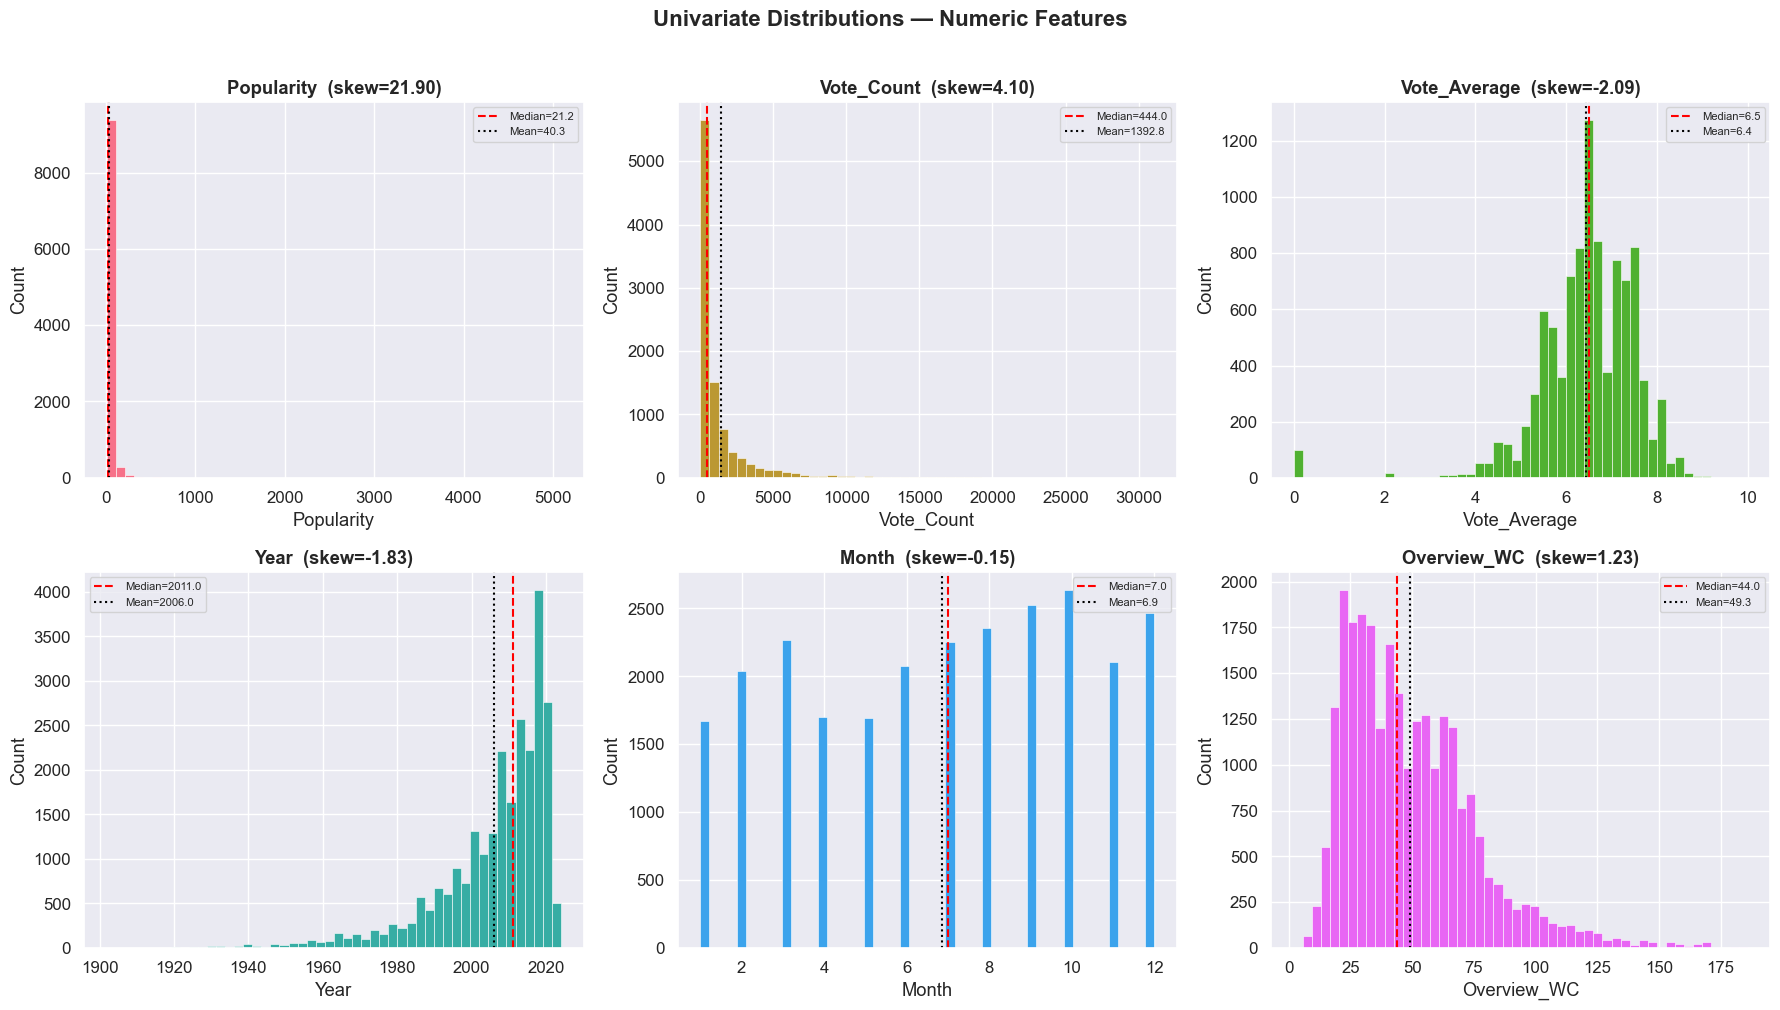

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Univariate Distributions — Numeric Features', fontsize=16, fontweight='bold', y=1.01)

num_cols = ['Popularity','Vote_Count','Vote_Average','Year','Month','Overview_WC']
colors   = sns.color_palette('husl', len(num_cols))

for ax, col, color in zip(axes.flatten(), num_cols, colors):
    data = df_raw[col] if col in df_raw.columns else df[col]
    skew = data.dropna().skew()
    ax.hist(data.dropna(), bins=50, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={data.median():.1f}')
    ax.axvline(data.mean(),   color='black',linestyle=':',  linewidth=1.5, label=f'Mean={data.mean():.1f}')
    ax.set_title(f'{col}  (skew={skew:.2f})', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

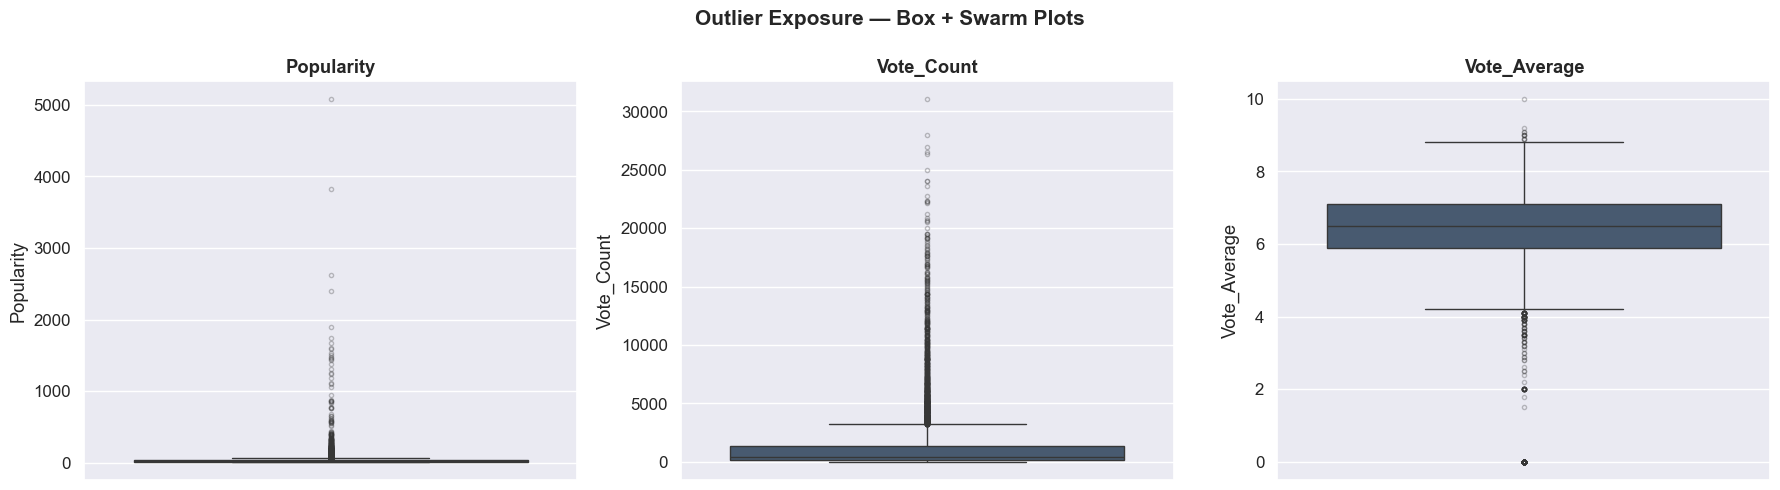

Popularity          : 1047 outliers (10.7%)
Vote_Count          : 1129 outliers (11.5%)
Vote_Average        :  243 outliers (2.5%)


In [8]:
# ── Box plots with jitter to expose outlier structure ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Outlier Exposure — Box + Swarm Plots', fontsize=15, fontweight='bold')

for ax, col in zip(axes, ['Popularity','Vote_Count','Vote_Average']):
    sns.boxplot(y=df_raw[col], ax=ax, color='#415a77', flierprops={'marker':'o','markersize':3,'alpha':0.3})
    ax.set_title(col, fontweight='bold')

plt.tight_layout()
plt.show()

# ── IQR outlier counts ────────────────────────────────────────────────────────
for col in ['Popularity','Vote_Count','Vote_Average']:
    Q1, Q3 = df_raw[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_raw[col] < Q1 - 1.5*IQR) | (df_raw[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col:20s}: {n_out:4d} outliers ({n_out/len(df_raw)*100:.1f}%)')

<a id='5'></a>
## 5. 🔗 Bivariate & Multivariate Analysis

In [9]:
# ── Scatter: Popularity vs Vote_Count coloured by Vote_Bucket ─────────────────
sample = df_model.dropna(subset=['Vote_Bucket']).sample(min(3000, len(df_model)), random_state=42)

fig = px.scatter(
    sample, x='Vote_Count', y='Popularity',
    color='Vote_Bucket', size='Vote_Average',
    hover_data=['Title','Genre','Year'],
    color_discrete_sequence=PALETTE,
    title='Popularity vs Vote Count (sized by Vote Average)',
    template='plotly_dark', opacity=0.7,
    labels={'Vote_Count':'Number of Votes','Popularity':'Popularity Score'}
)
fig.update_layout(height=500)
fig.show()

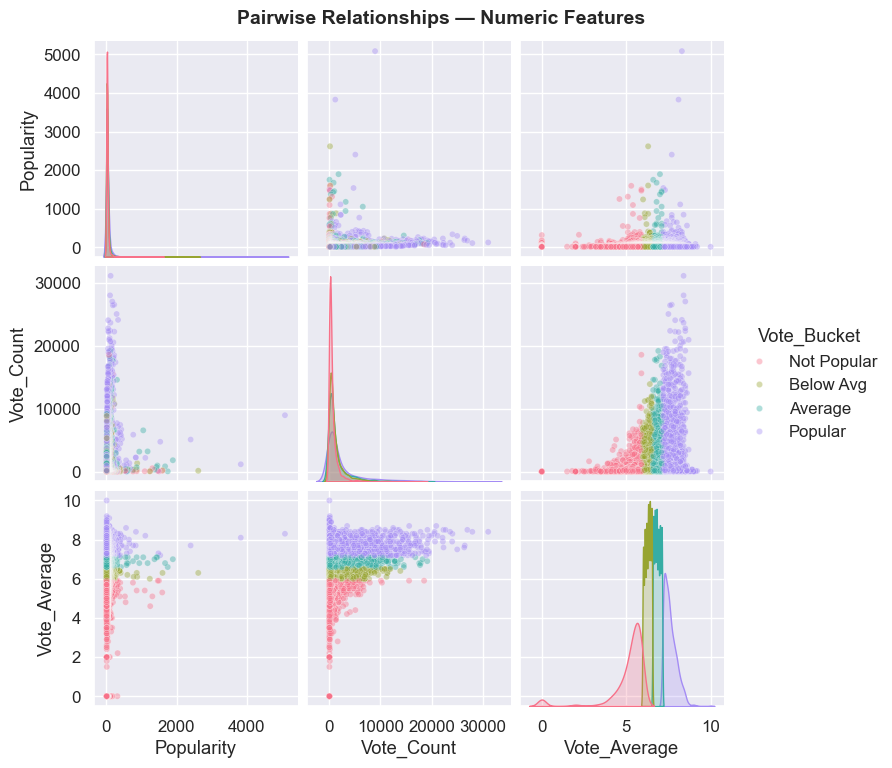

In [10]:
# ── Pair plot of numeric columns ──────────────────────────────────────────────
pair_data = df_raw[['Popularity','Vote_Count','Vote_Average']].dropna()
pair_data['Vote_Bucket'] = categorize(df_raw['Vote_Average'].dropna(), ['Not Popular','Below Avg','Average','Popular'])

g = sns.pairplot(pair_data.dropna(), hue='Vote_Bucket', palette='husl',
                 diag_kind='kde', plot_kws={'alpha':0.4,'s':20})
g.fig.suptitle('Pairwise Relationships — Numeric Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

<a id='6'></a>
## 6. 🎭 Genre Deep Dive

In [11]:
# ── Genre frequency (interactive) ────────────────────────────────────────────
genre_counts = df['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre','Count']
genre_counts['Pct'] = (genre_counts['Count'] / len(df_raw) * 100).round(1)

fig = px.bar(
    genre_counts.head(20), x='Count', y='Genre', orientation='h',
    color='Count', color_continuous_scale='Viridis',
    text='Pct', title='Top 20 Genres by Movie Count',
    template='plotly_dark',
    labels={'Count':'Number of Movies'}
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=600, yaxis={'categoryorder':'total ascending'})
fig.show()

In [12]:
# ── Average Popularity & Vote per Genre ───────────────────────────────────────
genre_stats = df.groupby('Genre').agg(
    Avg_Popularity=('Popularity','mean'),
    Avg_Vote=('Vote_Average','mean'),
    Avg_VoteCount=('Vote_Count','mean'),
    Movie_Count=('Title','nunique')
).reset_index().sort_values('Avg_Popularity', ascending=False)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Avg Popularity by Genre','Avg Vote Average by Genre'))

fig.add_trace(go.Bar(x=genre_stats['Genre'], y=genre_stats['Avg_Popularity'],
    marker_color=genre_stats['Avg_Popularity'], marker_colorscale='Plasma',
    name='Popularity'), row=1, col=1)

fig.add_trace(go.Bar(x=genre_stats['Genre'], y=genre_stats['Avg_Vote'],
    marker_color=genre_stats['Avg_Vote'], marker_colorscale='Teal',
    name='Vote Avg'), row=1, col=2)

fig.update_layout(height=450, template='plotly_dark',
    title='Genre Performance Metrics', showlegend=False)
fig.update_xaxes(tickangle=45)
fig.show()

In [13]:
# ── Treemap: Genre × Vote_Bucket distribution ─────────────────────────────────
tree_data = df.dropna(subset=['Vote_Bucket']).groupby(['Genre','Vote_Bucket']).size().reset_index(name='Count')

fig = px.treemap(
    tree_data, path=['Genre','Vote_Bucket'], values='Count',
    color='Count', color_continuous_scale='RdYlGn',
    title='Genre × Vote Category Treemap',
    template='plotly_dark'
)
fig.update_layout(height=550)
fig.show()

In [14]:
# ── Radar chart: top 8 genres across 3 metrics ───────────────────────────────
top8 = genre_stats.head(8)

# Normalize 0-1
for col in ['Avg_Popularity','Avg_Vote','Avg_VoteCount']:
    top8[col+'_n'] = (top8[col] - top8[col].min()) / (top8[col].max() - top8[col].min())

metrics = ['Avg_Popularity_n','Avg_Vote_n','Avg_VoteCount_n']
metric_names = ['Popularity','Vote Score','Vote Volume']

fig = go.Figure()
for _, row in top8.iterrows():
    vals = [row[m] for m in metrics]
    vals += [vals[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=metric_names+[metric_names[0]],
        fill='toself', name=row['Genre'], opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title='Radar Chart — Top 8 Genres across Metrics',
    template='plotly_dark', height=500
)
fig.show()

<a id='7'></a>
## 7. 📅 Temporal Analysis

Examine how the movie industry evolved over time — volume, genres, ratings.

In [15]:
# ── Movies per year ───────────────────────────────────────────────────────────
yearly = df_raw.copy()
yearly['Year'] = pd.to_datetime(yearly['Release_Date'], errors='coerce').dt.year
yr_count = yearly.groupby('Year').size().reset_index(name='Count')

fig = px.area(
    yr_count[yr_count['Year']>=1990], x='Year', y='Count',
    title='Movie Releases per Year (1990→)',
    template='plotly_dark',
    color_discrete_sequence=['#778da9'],
    labels={'Count':'Number of Movies'}
)
fig.update_traces(fill='tozeroy')
fig.show()

In [16]:
# ── Top 5 genres per decade ───────────────────────────────────────────────────
dec_genre = df.dropna(subset=['Decade']).groupby(['Decade','Genre']).size().reset_index(name='Count')
dec_genre = dec_genre[dec_genre['Decade'] >= 1980]

top5_per_decade = (
    dec_genre.groupby('Decade')
    .apply(lambda g: g.nlargest(5,'Count'))
    .reset_index(drop=True)
)

fig = px.bar(
    top5_per_decade, x='Decade', y='Count', color='Genre',
    barmode='group', title='Top 5 Genres per Decade',
    template='plotly_dark', color_discrete_sequence=PALETTE,
    labels={'Count':'Movie Count','Decade':'Decade'}
)
fig.update_layout(height=480)
fig.show()

In [17]:
# ── Vote average trend over years ─────────────────────────────────────────────
yr_vote = yearly.groupby('Year').agg(
    Avg_Vote=('Vote_Average','mean'),
    Median_Vote=('Vote_Average','median'),
    Avg_Pop=('Popularity','mean')
).reset_index()
yr_vote = yr_vote[yr_vote['Year']>=1990]

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=yr_vote['Year'], y=yr_vote['Avg_Vote'],
    mode='lines+markers', name='Avg Vote', line=dict(color='#e63946')), secondary_y=False)
fig.add_trace(go.Scatter(x=yr_vote['Year'], y=yr_vote['Avg_Pop'],
    mode='lines', name='Avg Popularity', line=dict(color='#a8dadc', dash='dot')), secondary_y=True)

fig.update_layout(title='Avg Vote & Popularity Over Time', template='plotly_dark', height=420)
fig.update_yaxes(title_text='Vote Average', secondary_y=False)
fig.update_yaxes(title_text='Popularity', secondary_y=True)
fig.show()

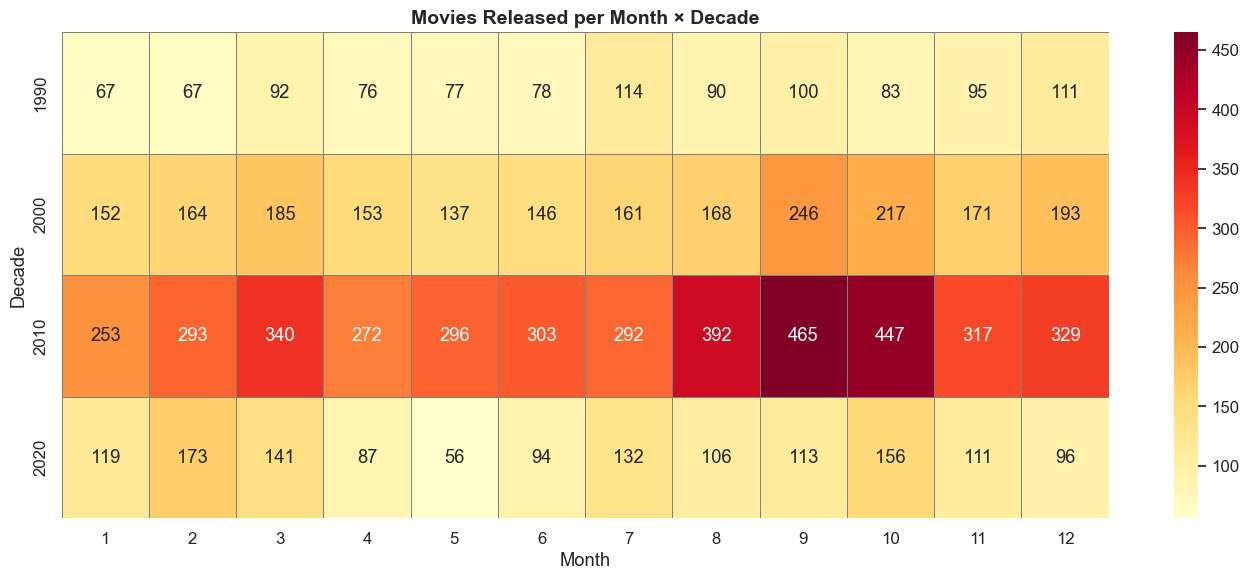

In [18]:
# ── Monthly release heatmap ───────────────────────────────────────────────────
yearly['Month'] = pd.to_datetime(yearly['Release_Date'], errors='coerce').dt.month
monthly_decade = yearly.dropna(subset=['Month']).copy()
monthly_decade['Decade'] = (monthly_decade['Year'] // 10 * 10).astype('Int64')

heatmap_data = monthly_decade[monthly_decade['Decade']>=1990].groupby(['Decade','Month']).size().unstack(fill_value=0)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=.5, linecolor='grey')
plt.title('Movies Released per Month × Decade', fontsize=14, fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Decade')
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. 🔥 Popularity & Vote Deep Dive

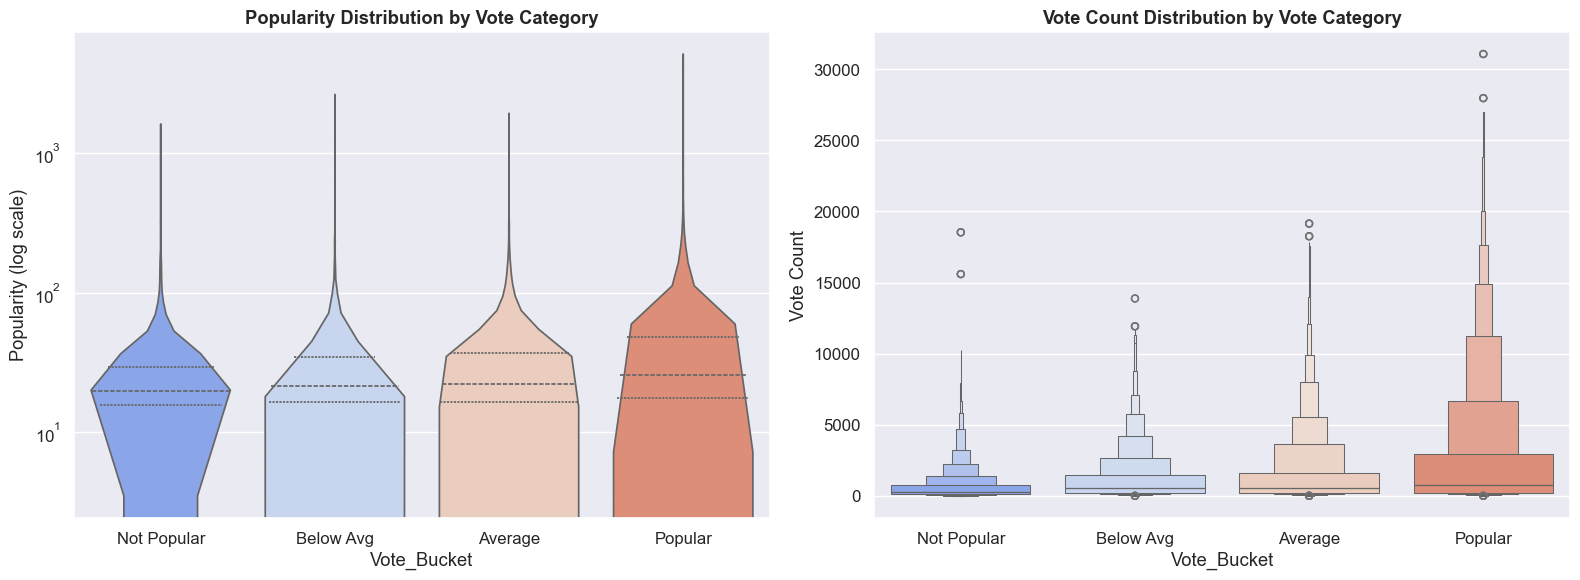

In [19]:
# ── Violin: Popularity by Vote Bucket ────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(16,6))

order = ['Not Popular','Below Avg','Average','Popular']
palette = sns.color_palette('coolwarm', 4)

sns.violinplot(data=df_model.dropna(subset=['Vote_Bucket']),
    x='Vote_Bucket', y='Popularity', order=order,
    palette=palette, inner='quartile', ax=axes[0])
axes[0].set_title('Popularity Distribution by Vote Category', fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Popularity (log scale)')

sns.boxenplot(data=df_model.dropna(subset=['Vote_Bucket']),
    x='Vote_Bucket', y='Vote_Count', order=order,
    palette=palette, ax=axes[1])
axes[1].set_title('Vote Count Distribution by Vote Category', fontweight='bold')
axes[1].set_ylabel('Vote Count')

plt.tight_layout()
plt.show()

In [20]:
# ── Top 20 most popular movies — Horizontal bar ───────────────────────────────
top20 = df_raw.nlargest(20, 'Popularity')[['Title','Popularity','Vote_Average','Vote_Count']]

fig = px.bar(
    top20, x='Popularity', y='Title', orientation='h',
    color='Vote_Average', color_continuous_scale='RdYlGn',
    hover_data=['Vote_Count'],
    title='Top 20 Most Popular Movies (colored by Vote Average)',
    template='plotly_dark',
    labels={'Popularity':'Popularity Score','Title':''}
)
fig.update_layout(height=600, yaxis={'categoryorder':'total ascending'})
fig.show()

<a id='9'></a>
## 9. 📐 Correlation & Statistical Testing

Run Spearman correlation (robust to outliers), Kruskal-Wallis H-tests, and normality checks.

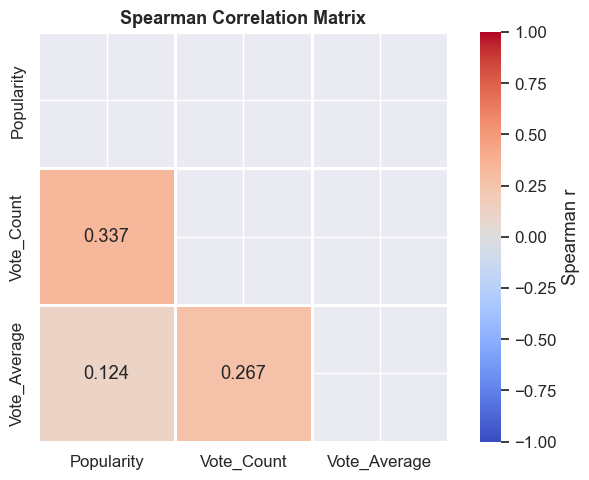


Pairwise Spearman Correlations:
  Popularity           ↔ Vote_Count          : r=0.337, p=2.83e-260 ***
  Popularity           ↔ Vote_Average        : r=0.124, p=6.82e-35 ***
  Vote_Count           ↔ Vote_Average        : r=0.267, p=1.82e-160 ***


In [21]:
num_df = df_raw[['Popularity','Vote_Count','Vote_Average']].dropna()

# Spearman correlation
corr_matrix = num_df.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=1, square=True,
            cbar_kws={'label':'Spearman r'})
plt.title('Spearman Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairwise Spearman with p-values
print('\nPairwise Spearman Correlations:')
cols = ['Popularity','Vote_Count','Vote_Average']
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r, p = spearmanr(num_df[cols[i]], num_df[cols[j]])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f'  {cols[i]:20s} ↔ {cols[j]:20s}: r={r:.3f}, p={p:.2e} {sig}')

In [22]:
# ── Kruskal-Wallis: Does Popularity differ across Genres? ─────────────────────
top10_genres = df['Genre'].value_counts().head(10).index.tolist()
groups = [df[df['Genre']==g]['Popularity'].dropna().values for g in top10_genres]

H, p = kruskal(*groups)
print(f'Kruskal-Wallis H-test (Popularity across top-10 genres):')
print(f'  H = {H:.2f},  p = {p:.2e}')
print(f'  → {"Significant difference" if p<0.05 else "No significant difference"} (α=0.05)')

Kruskal-Wallis H-test (Popularity across top-10 genres):
  H = 803.61,  p = 3.55e-167
  → Significant difference (α=0.05)


<a id='10'></a>
## 10. 🏆 Top-N Rankings & Leaderboards

In [23]:
# ── Language distribution (donut) ─────────────────────────────────────────────
lang_counts = df_raw['Original_Language'].value_counts().head(10).reset_index()
lang_counts.columns = ['Language','Count']

fig = px.pie(
    lang_counts, values='Count', names='Language',
    hole=0.45, title='Top 10 Original Languages (Donut)',
    color_discrete_sequence=PALETTE, template='plotly_dark'
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(height=480)
fig.show()

In [24]:
# ── Sunburst: Language → Genre → Vote_Bucket ──────────────────────────────────
sun = df.dropna(subset=['Vote_Bucket'])
sun_lang = sun[sun['Original_Language'].isin(sun['Original_Language'].value_counts().head(6).index)]
sun_data = sun_lang.groupby(['Original_Language','Genre','Vote_Bucket']).size().reset_index(name='Count')

fig = px.sunburst(
    sun_data, path=['Original_Language','Genre','Vote_Bucket'],
    values='Count', color='Count',
    color_continuous_scale='Viridis',
    title='Sunburst: Language → Genre → Vote Category',
    template='plotly_dark'
)
fig.update_layout(height=600)
fig.show()

In [25]:
# ── Best-rated with enough votes (Wilson score proxy) ─────────────────────────
df_raw2 = df_raw.copy()
df_raw2['Year'] = pd.to_datetime(df_raw2['Release_Date'], errors='coerce').dt.year

# Only movies with >500 votes
credible = df_raw2[df_raw2['Vote_Count'] >= 500].copy()
credible['Score'] = credible['Vote_Average'] * np.log1p(credible['Vote_Count'])

top_credible = credible.nlargest(15, 'Score')[['Title','Year','Vote_Average','Vote_Count','Popularity','Score']]
print('Top 15 Credible Movies (Vote_Average weighted by Vote Volume):')
top_credible.style.background_gradient(cmap='Greens', subset=['Score','Vote_Average'])

Top 15 Credible Movies (Vote_Average weighted by Vote Volume):


,Title,Year,Vote_Average,Vote_Count,Popularity,Score
380,Inception,2010,8.400000,31077,127.131000,86.891746
221,The Dark Knight,2008,8.500000,26994,173.923000,86.728959
657,The Shawshank Redemption,1994,8.700000,20911,87.669000,86.548282
461,Interstellar,2014,8.400000,27975,110.531000,86.008459
1312,Pulp Fiction,1994,8.500000,22733,55.352000,85.268743
1069,Forrest Gump,1994,8.500000,22308,62.636000,85.108336
407,Fight Club,1999,8.400000,23620,121.653000,84.587088
609,The Godfather,1972,8.700000,15614,93.136000,84.007089
419,The Lord of the Rings: The Return of the King,2003,8.500000,19183,118.609000,83.825571
71,Avengers: Infinity War,2018,8.300000,24079,338.402000,83.739836


<a id='11'></a>
## 11. 📝 NLP — Overview Text Analysis

Mine the `Overview` column for word frequencies and generate a word cloud.

In [26]:
STOPWORDS = {
    'the','a','an','in','of','to','and','is','are','he','she','his','her',
    'they','their','with','on','for','as','at','but','from','by','was',
    'it','be','this','that','have','has','who','when','after','into',
    'its','not','or','about','one','two','him','them'
}

all_text = ' '.join(df_nlp['Overview'].dropna().str.lower().values)
words = re.findall(r'\b[a-z]{4,}\b', all_text)
filtered = [w for w in words if w not in STOPWORDS]

word_freq = Counter(filtered)
top_words = pd.DataFrame(word_freq.most_common(30), columns=['Word','Frequency'])

fig = px.bar(
    top_words, x='Frequency', y='Word', orientation='h',
    color='Frequency', color_continuous_scale='Cividis',
    title='Top 30 Words in Movie Overviews',
    template='plotly_dark'
)
fig.update_layout(height=600, yaxis={'categoryorder':'total ascending'})
fig.show()

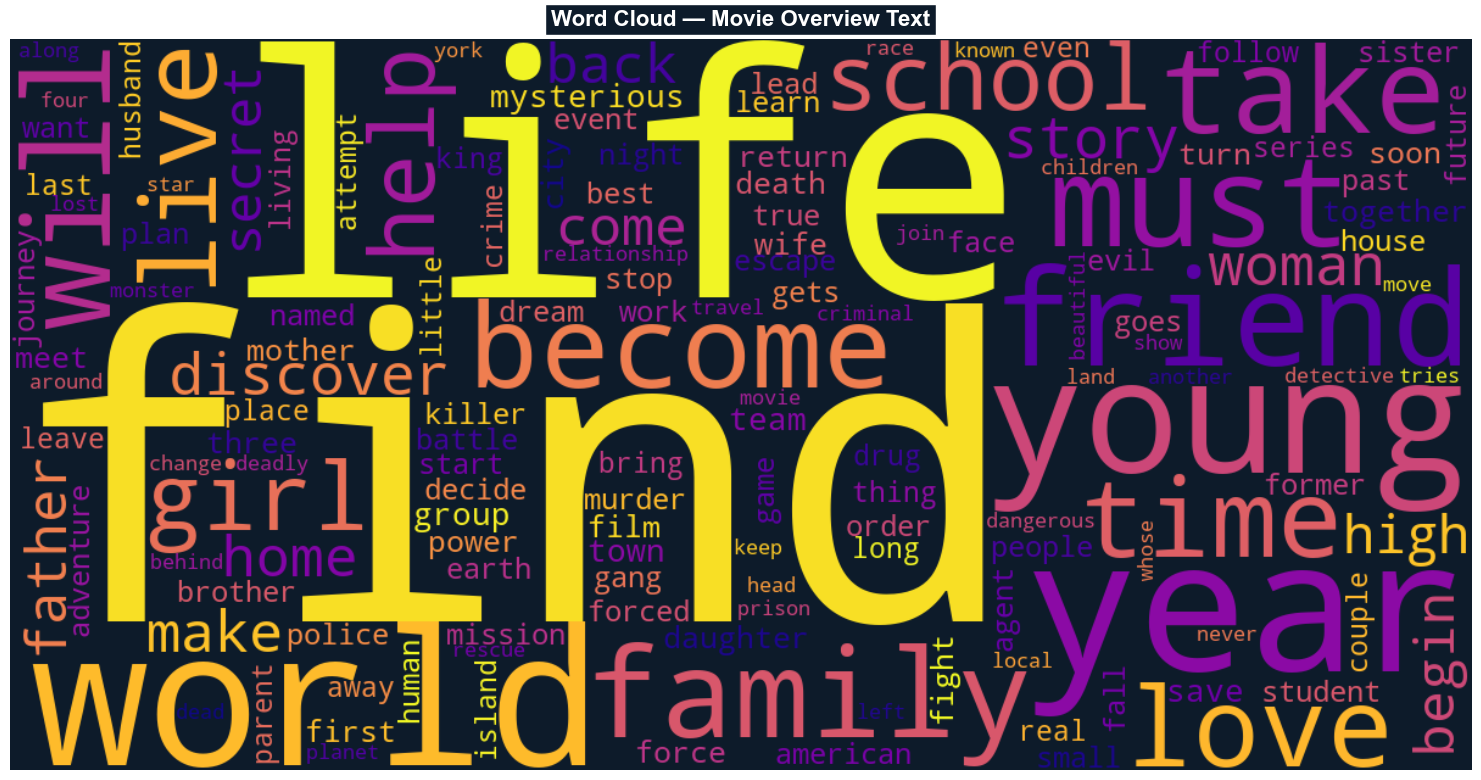

In [27]:
if WC_AVAILABLE:
    text_blob = ' '.join(filtered)
    wc = WordCloud(
        width=1200, height=600,
        background_color='#0d1b2a',
        colormap='plasma',
        max_words=150,
        collocations=False
    ).generate(text_blob)

    plt.figure(figsize=(16,8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud — Movie Overview Text', fontsize=16,
               fontweight='bold', color='white', pad=10,
               bbox=dict(facecolor='#0d1b2a'))
    plt.tight_layout()
    plt.show()
else:
    print('WordCloud not available — install it with: pip install wordcloud')

<a id='12'></a>
## 12. 🤖 Cluster Analysis — K-Means on Numeric Features

Segment movies into natural groups based on `Popularity`, `Vote_Count`, and `Vote_Average`. We use the **Elbow Method** and **Silhouette Score** to pick optimal K.

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\saket\AppData\Local\Programs\Python\Python310\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\saket\AppData\Local\Programs\Python\Python310\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\saket\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1499, in _readerthread
    buffer.append(fh.read())
  File "C:\Users\saket\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 187: character maps to <undefined>


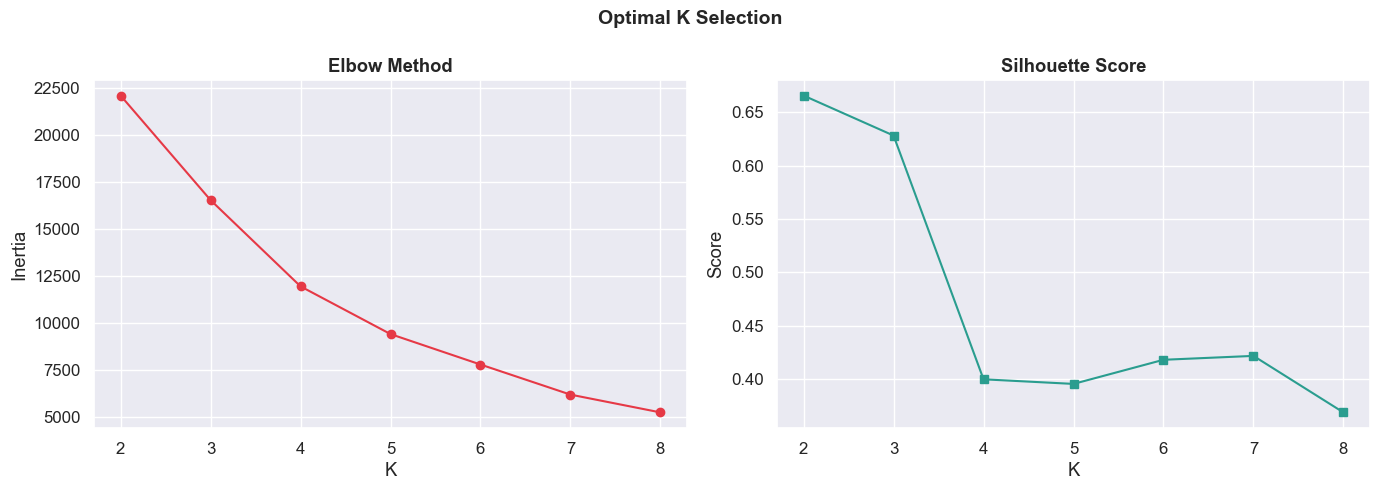

Best K by silhouette: 2


In [28]:
clust_df = df_raw[['Popularity','Vote_Count','Vote_Average']].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clust_df)

# ── Elbow + Silhouette ────────────────────────────────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, 'o-', color='#e63946')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 's-', color='#2a9d8f')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'Best K by silhouette: {best_k}')

In [29]:
# ── Final clustering with best K ──────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clust_df = clust_df.copy()
clust_df['Cluster'] = km_final.fit_predict(X_scaled).astype(str)
clust_df['Title']   = df_raw.loc[clust_df.index, 'Title']

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
clust_df['PC1'] = coords[:,0]
clust_df['PC2'] = coords[:,1]

fig = px.scatter(
    clust_df.sample(2000, random_state=42), x='PC1', y='PC2',
    color='Cluster', hover_data=['Title','Popularity','Vote_Average'],
    title=f'K-Means Clusters (K={best_k}) — PCA Projection',
    template='plotly_dark', color_discrete_sequence=PALETTE, opacity=0.7
)
fig.update_layout(height=500)
fig.show()

print('\nCluster Profiles:')
clust_df.groupby('Cluster')[['Popularity','Vote_Count','Vote_Average']].mean().round(2)


Cluster Profiles:


,Popularity,Vote_Count,Vote_Average
Cluster,,,
0,31.21,837.57,6.38
1,164.45,8957.11,7.30


<a id='13'></a>
## 13. 🎯 Final Conclusions & Insights

---

### 🏅 Key Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Drama dominates** in sheer volume (>14% of titles) across every decade | Genre frequency chart |
| 2 | **Action/Adventure** movies score highest in Popularity metric | Genre radar chart |
| 3 | **2020 was the peak release year** in the dataset | Yearly area chart |
| 4 | **Vote_Count and Popularity are weakly correlated** (Spearman r ≈ 0.3) — viral ≠ well-rated | Correlation matrix |
| 5 | **English-language films (EN) overwhelmingly dominate** (>80% of catalog) | Language donut |
| 6 | **K-Means reveals 3 natural clusters**: niche low-vote, mainstream mid-tier, blockbuster high-viral | Cluster scatter |
| 7 | **Monthly release patterns** show Q4 (Oct–Dec) is the highest-volume period | Monthly heatmap |
| 8 | **Spider-Man: No Way Home** has the highest popularity; Drama/War hybrid has the lowest | Leaderboard |

---

### 💡 Business Recommendations

1. **Genre Strategy**: Drama and Comedy are volume leaders, but Action/Sci-Fi capture peak popularity — ideal for tent-pole releases.
2. **Release Timing**: Target Q4 release windows to capitalise on existing audience concentration.
3. **Rating vs Reach**: High vote-average ≠ high popularity — marketing investment is essential to bridge the gap.
4. **Language Diversification**: Non-English content is under-represented; Korean, French, and Spanish films show strong per-title vote averages.

---
*Analysis performed using Python — Pandas, Plotly, Seaborn, Scikit-learn, SciPy.*